# Cheng's ideational consistency: a size effect, not reach

**Artifact:** `art_UkIMstVveAFx` (experiment) · **Source script:** `method.py` plus the `lib/` step modules it runs

This notebook re-runs, on a **100-concept demo subset**, the pipeline that `method.py` orchestrates. The pipeline rebuilds
Cheng et al. (2023, *ASR* 88:522-561), where **ideational consistency** of a concept in year *t* is

$$\mathrm{CONS}(t)=\cos\big(v_{t-1},\,v_t\big),$$

with $v_t[k]$ = the number of year-*t* papers of the concept (in its home fields) tagged with OpenAlex topic *k*, and the
concept's own "self" topics dropped. The pipeline then asks whether consistency predicts **reach** (spread across fields), or
only **size**:

| step | what it does | in this demo |
|---|---|---|
| S0 | freeze the spec and verdict rules before any model | rules copied into the verdict cell |
| S1 | build CONS, CONS_r, EMB, SOC per concept × year (HOME / ALL paper sets) | CONS / CONS_r **recomputed from the topic vectors**; EMB and SOC loaded from the stored run |
| S2 | construct-identity check against Exp11 | not in the demo (needs Exp11 tables) |
| S3 | **Test A**: Cheng replication panel `V(t+1) ~ zCONS + zEMB + zSOC`, then + `log V(t)` | run (HOME build) |
| S4 | **Test B**: early trait vs later reach / depth (partial Spearman given the B5 baseline) | run |
| S5 | **Test C**: within-concept panel | not in the demo (needs the Exp11 yearly panel) |
| S6 | **Test D**: Palla size × consistency interaction | run |
| S7 | **Test E**: HOME vs ALL coupling | run |
| S8 | mechanical verdict | run on the demo numbers |

The demo data (`mini_demo_data.json`) holds 100 EXP5 frame concepts, stratified over the six field groups. Transient
concepts ($O3=1$, about 4% of the frame) are oversampled to 2 per group so that the transience outcome varies. Each concept
has its B5 baseline, its outcomes and, for every year $t_0-1 \ldots t_0+11$, its sparse HOME topic co-usage vector and its
grounded volume $V(t)$. With 100 concepts instead of 12,499, the confidence intervals are wide. The last cell sets the
demo estimates beside the full-run headline numbers. **All numbers are selection data, not confirmation.**

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest -- NOT on Colab, always install (PPML / OLS with fixed effects, as in the original run)
_pip('pyfixest==0.60.0')

# numpy, pandas, scipy, statsmodels, matplotlib -- pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

In [2]:
# ---- original method.py import block
from __future__ import annotations

import argparse
import os
import sys

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):   # one BLAS thread per process: the
    os.environ.setdefault(_v, "1")                                         # steps parallelise across processes
import time
from pathlib import Path

# ---- imports of the lib/ modules that method.py runs (common, cheng, build, panel_cheng, static_cheng, rq1stats, outputs)
import math
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

# ---- notebook additions
import json
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("concepts in file:", len(data["datasets"][0]["examples"]), "| OpenAlex topics:", data["metadata"]["n_topics"])

Demo subset of experiment art_UkIMstVveAFx (Cheng et al. 2023 ideational consistency on OpenAlex topic co-usage): 100 EXP5 frame concepts stratified by field group and body; transient concepts (O3 == 1) oversampled to 2 per group so that the rare transience outcome varies.
concepts in file: 100 | OpenAlex topics: 4516


## Configuration

These are all the tunable parameters. The original values (from `lib/common.py` and the `run_*` functions) appear in
the comments. On 100 concepts the full bootstrap counts take well under a minute, so the demo uses them unchanged. In
the original run, `--quick` mode used 60 / 100 draws.

In [5]:
N_CONCEPTS = 100            # demo concepts used (the file holds 100; the original run used 12,499 EXP5 + 1,443 cohort concepts)
N_BOOT_PANEL = 500        # original: 500  (test A: concept-cluster bootstrap of the A2/A1 ratio)
N_BOOT_STATIC = 2000      # original: 2000 (test B primary trait; test E)
N_BOOT_SECONDARY = 500  # original: 500  (test B secondary traits / ALL-build volume)
N_BOOT_GROUP = 1000        # original: 1000 (test B per-group psp; groups need >= 40 concepts)
N_BOOT_PALLA = 1000        # original: 1000 (test D)
WORKERS = 1                          # original: all cores via ProcessPoolExecutor; the notebook runs sequentially

## Shared constants (`lib/common.py`)

These are the frozen definitions from `lib/common.py`. CONS is defined only for years with at least 3 papers and at least
2 non-self topics. The **B5 baseline** is the five early descriptors that every partial correlation controls for: early
log volume, early growth, off-home share, field entropy and field reach. The outcomes fall into two families:
**depth** (`O1c` continued home uptake, `O1b` sustained-uptake flag, `O3` transience) and **reach** (`O2r_m50` rarefied
venue-field richness at $t_0+6..8$; `O2r_resid` is its size residual).

In [6]:
SEED = 20260929
MIN_PAPERS = 3                      # CONS / EMB defined iff >= 3 papers ...
MIN_TOPICS = 2                      # ... and >= 2 non-self topics in BOTH years (CONS) / in year t (EMB)

# frame group -> the five pooled groups of EXP10 (MATHDEC reported only)
GROUP5 = {"CS": "CS+Eng", "Eng": "CS+Eng", "BGM": "BGM+Med", "Med": "BGM+Med", "PHYS": "PHYS",
          "LIFEENV": "LIFEENV", "SOC": "SOC", "MATHDEC": "MATHDEC"}
GROUPS5 = ["CS+Eng", "BGM+Med", "PHYS", "LIFEENV", "SOC"]
BODIES_EXP5 = ["DEV", "OLD_HELDOUT", "COHORT_2010_14"]
BODY_COHORT = "COHORT_2015_17"
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
DEPTH = ["O1c", "O1b", "O3"]
REACH = ["O2r_m50", "O2r_resid"]
SELECTION_LABEL = "selection data, not confirmation"

## Load the demo concepts into the pipeline's tables

The original S1 step reads its inputs from the run's parquet caches: the grounded OpenAlex rows, the frame concept list
and $V(t)$. This cell rebuilds the same tables from the loaded `data` instead:

* `meta`: one row per concept (`ci, body, t0, group, group5`), which is what `build.run` builds from `frame_concepts.csv`;
* `V_demo`: grounded yearly volume `(ci, year, V)`, which replaces `data/V_exp5.parquet`;
* `yrs`: the per-concept yearly records (topic vectors plus the stored EMB / SOC);
* `st_demo`: the static B5, outcome and volume columns that `static_cheng.static_frame` takes from the EXP8 analysis table.

In [7]:
examples = data["datasets"][0]["examples"][:N_CONCEPTS]
NT = data["metadata"]["n_topics"]

st_demo = pd.DataFrame([{k[len("metadata_"):]: v for k, v in ex.items()
                         if k.startswith("metadata_") and k != "metadata_years"} for ex in examples])
meta = st_demo[["ci", "body", "t0", "group", "group5"]].copy()
V_demo = pd.DataFrame([{"ci": ex["metadata_ci"], "year": r["year"], "V": r["V"]}
                       for ex in examples for r in ex["metadata_years"]])
yrs = {ex["metadata_ci"]: {r["year"]: r for r in ex["metadata_years"]} for ex in examples}
print(f"{len(meta)} concepts;", meta.group5.value_counts().to_dict(), meta.body.value_counts().to_dict())
st_demo.head()

100 concepts; {'BGM+Med': 17, 'CS+Eng': 17, 'LIFEENV': 17, 'PHYS': 17, 'SOC': 17, 'MATHDEC': 15} {'COHORT_2010_14': 42, 'OLD_HELDOUT': 37, 'DEV': 21}


,ci,t0,group,group5,body,split,name,window_flag,V_t0p2,V_t0p3,...,O1b,O3,CONS_early_home,CONS_early_all,CONS_r_early_home,EMB_early_home,EMB_cos_early_home,SOC_early_home,home_vfields,n_self_topics
0,150,2011,Med,BGM+Med,COHORT_2010_14,COHORT,HRAS,0,31.0,24.0,...,1.0,0.0,0.580345,0.573475,0.714323,1.430733,0.236404,0.008134,"[3, 17]",0
1,28723,2011,Med,BGM+Med,COHORT_2010_14,COHORT,Abiraterone,0,44.0,87.0,...,1.0,0.0,0.606676,0.616624,0.712531,1.225991,0.168193,0.006648,[17],5
2,38265,2011,Med,BGM+Med,COHORT_2010_14,COHORT,Kexin,0,44.0,43.0,...,1.0,0.0,0.478739,0.562960,0.633462,1.119513,0.217345,0.003827,[17],2
3,44960,2013,Med,BGM+Med,COHORT_2010_14,COHORT,Bedaquiline,0,43.0,60.0,...,1.0,0.0,0.456415,0.697332,0.666812,1.548833,0.196007,0.007932,[17],4
4,49757,2010,Med,BGM+Med,COHORT_2010_14,COHORT,Bone Sarcoma,0,19.0,11.0,...,1.0,0.0,0.479095,0.463157,0.682694,0.991474,0.164515,0.028544,[17],3


## S1: Cheng's measures (`lib/cheng.py`)

This is the core measure, copied verbatim. `cons()` returns the cosine of the non-self topic co-usage vectors of years
$t-1$ and $t$ (**CONS**). It also returns Cheng's verbatim variant **CONS_r**, which restricts $v_t$ to the topics that
already appeared in $t-1$. Both are NaN unless each year has at least 3 papers and at least 2 non-self topics.

In [8]:
def cosine(u: np.ndarray, v: np.ndarray) -> float:
    nu, nv = float(np.sqrt(u @ u)), float(np.sqrt(v @ v))
    if nu == 0 or nv == 0:
        return 0.0
    return float(u @ v / (nu * nv))


def cons(v_prev: np.ndarray, v_cur: np.ndarray, n_prev: int, n_cur: int) -> tuple[float, float]:
    """(CONS, CONS_r). NaN unless both years have >= MIN_PAPERS papers and >= MIN_TOPICS non-self topics."""
    if n_prev < MIN_PAPERS or n_cur < MIN_PAPERS:
        return float("nan"), float("nan")
    if (v_prev > 0).sum() < MIN_TOPICS or (v_cur > 0).sum() < MIN_TOPICS:
        return float("nan"), float("nan")
    c = cosine(v_prev, v_cur)
    supp = v_prev > 0
    vr = np.where(supp, v_cur, 0.0)
    cr = cosine(v_prev, vr)
    return c, cr

### Per concept × year feature rows (the loop of `cheng.concept_measures`)

For each concept and each year $t_0 \le t \le \min(t_0+10, 2022)$, this cell rebuilds the dense non-self HOME vector
$v_t$ from the stored sparse counts and applies `cons()`, following the loop in `concept_measures`. The EMB analogue
needs the PMI backbone, and SOC needs co-author lists. Neither ships with the demo, so their per-year values are taken
from the original run. The ALL build supplies only its stored CONS, which Test E uses. The cell then checks that the
recomputed CONS matches the stored value.

In [9]:
MEAS = ["CONS", "CONS_r", "EMB", "EMB_cos", "SOC"]


def dense(rec: dict) -> np.ndarray:
    v = np.zeros(NT)
    v[rec.get("topic_ids", [])] = rec.get("topic_counts", [])
    return v


rows, max_dev = [], 0.0
for r0 in meta.itertuples():
    ci, t0 = int(r0.ci), int(r0.t0)
    y_lo, y_hi = t0, int(min(t0 + 10, 2022))
    R = yrs[ci]
    for t in range(y_lo, y_hi + 1):
        v = dense(R[t])
        n_cur = int(R[t].get("n_papers_topic", 0))
        r = {"ci": ci, "year": t, "build": "HOME", "n_papers": n_cur, "n_topics": int((v > 0).sum())}
        vp = dense(R[t - 1])
        r["CONS"], r["CONS_r"] = cons(vp, v, int(R[t - 1].get("n_papers_topic", 0)), n_cur)
        # EMB / EMB_cos / SOC need the PMI backbone and co-author lists -> stored values of the original run
        r["EMB"], r["EMB_cos"], r["SOC"] = (np.nan if R[t].get(k) is None else R[t][k] for k in ("EMB", "EMB_cos", "SOC"))
        r["n_authors"] = R[t].get("n_authors", 0)
        s = R[t].get("CONS")
        if s is not None or math.isfinite(r["CONS"]):
            max_dev = max(max_dev, abs(r["CONS"] - s) if (s is not None and math.isfinite(r["CONS"])) else 1.0)
        rows.append(r)
        rows.append({"ci": ci, "year": t, "build": "ALL", "n_papers": np.nan, "n_topics": np.nan,
                     "CONS": np.nan if R[t].get("CONS_all") is None else R[t]["CONS_all"], "CONS_r": np.nan,
                     "EMB": np.nan, "EMB_cos": np.nan, "SOC": np.nan, "n_authors": np.nan})
feat = pd.DataFrame(rows)
fh = feat[feat.build == "HOME"]
print(f"feature rows: {len(feat)} ({len(fh)} HOME); finite HOME CONS: {np.isfinite(fh.CONS).sum()}")
print(f"max |recomputed CONS - stored CONS| = {max_dev:.2e}")
print("HOME CONS quantiles:", np.round(np.nanquantile(fh.CONS, [0, .1, .25, .5, .75, .9, 1]), 3))

feature rows: 2168 (1084 HOME); finite HOME CONS: 1055
max |recomputed CONS - stored CONS| = 0.00e+00
HOME CONS quantiles: [0.    0.201 0.373 0.539 0.689 0.799 0.975]


### Static early traits (`build.static_table`, verbatim)

A concept's **early trait** is the mean of each measure over $t_0+1..t_0+2$, taken separately for each build. For example,
`CONS_early_home` is Test B's main predictor. The cell compares the result with the value stored in the original run.

In [10]:
def static_table(feat: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    f = feat.merge(meta[["ci", "t0"]], on="ci")
    f = f[(f.year >= f.t0 + 1) & (f.year <= f.t0 + 2)]
    g = f.groupby(["ci", "build"])[MEAS].mean().unstack("build")
    g.columns = [f"{m}_early_{b.lower()}" for m, b in g.columns]
    g = g.reset_index()
    # early support diagnostics (HOME build)
    fh = f[f.build == "HOME"].groupby("ci").agg(n_papers_early_home=("n_papers", "sum"),
                                                deg_early_home=("n_topics", "mean"),
                                                n_authors_early_home=("n_authors", "sum")).reset_index()
    return meta[["ci", "body", "t0", "group", "group5"]].merge(g, on="ci", how="left").merge(fh, on="ci", how="left")


st = static_table(feat, meta)
chk = st.merge(st_demo[["ci", "CONS_early_home", "CONS_early_all"]], on="ci", suffixes=("", "_stored"))
print("max |CONS_early_home - stored| =", float(np.nanmax(np.abs(chk.CONS_early_home - chk.CONS_early_home_stored))))
print("max |CONS_early_all  - stored| =", float(np.nanmax(np.abs(chk.CONS_early_all - chk.CONS_early_all_stored))))
st[["ci", "group5", "CONS_early_home", "CONS_early_all", "EMB_early_home", "SOC_early_home"]].head()

max |CONS_early_home - stored| = 0.0
max |CONS_early_all  - stored| = 0.0


,ci,group5,CONS_early_home,CONS_early_all,EMB_early_home,SOC_early_home
0,150,BGM+Med,0.580345,0.573475,1.430733,0.008134
1,28723,BGM+Med,0.606676,0.616624,1.225991,0.006648
2,38265,BGM+Med,0.478739,0.562960,1.119513,0.003827
3,44960,BGM+Med,0.456415,0.697332,1.548833,0.007932
4,49757,BGM+Med,0.479095,0.463157,0.991474,0.028544


## Meta-analysis and multiplicity helpers (`lib/rq1stats.py`, verbatim)

These are the DerSimonian-Laird random-effects pooling across field groups and the Holm adjustment used by the verdict.

In [11]:
def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()

## S3 · Test A: Cheng's replication panel (`lib/panel_cheng.py`)

The panel uses concept-years with $t_0+1 \le t \le \min(t_0+10, 2021)$ and a finite CONS. Every model is a Poisson (PPML)
regression of next-year volume on z-scored measures, with CRV1 standard errors clustered by concept:

* **A1** `V(t+1) ~ zCONS + zEMB + zSOC | age + year`, which is Cheng's specification;
* **A2** = A1 + `log1p V(t)`, the **size control**;
* **A3** = A2 with concept fixed effects;
* **A1-NB** is a negative-binomial twin of A1.

The key quantity is the **ratio** $b_{A2}/b_{A1}$ on zCONS. A ratio near 0 means consistency predicts next-year volume
only because it tracks current size. The confidence interval comes from a concept-cluster bootstrap that fits both models
on the same draws with a numpy Poisson IRLS; the original run validated this IRLS against pyfixest.

The first cell is `panel_A`. It keeps the original body but reads the in-memory `feat`, `meta` and `V_demo` in place of
the parquet files.

In [12]:
XS_JOINT = ["zCONS", "zEMB", "zSOC"]


def panel_A(build: str) -> pd.DataFrame:
    fr = meta[["ci", "t0", "group", "body", "group5"]]            # was: EXP5 frame_concepts.csv
    f = feat                                                        # was: data/cheng_features.parquet
    f = f[(f.build == build)][["ci", "year", "CONS", "EMB", "SOC", "n_papers", "n_topics"]]
    V = V_demo[["ci", "year", "V"]]                                 # was: data/V_exp5.parquet
    d = f.merge(fr, on="ci")
    d = d[(d.year >= d.t0 + 1) & (d.year <= np.minimum(d.t0 + 10, 2021))]
    d = d.merge(V, on=["ci", "year"], how="left").merge(
        V.assign(year=V.year - 1).rename(columns={"V": "V_next"}), on=["ci", "year"], how="left")
    d = d[np.isfinite(d.CONS)].copy()
    d["age"] = d.year - d.t0
    d["logV"] = np.log1p(d.V)
    return d.reset_index(drop=True)


def zcols(d: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    d = d.copy()
    for c in cols:
        v = d[c].to_numpy(float)
        d["z" + c] = (v - np.nanmean(v)) / np.nanstd(v)
    return d

### numpy Poisson IRLS with dummy fixed effects, and the concept-cluster bootstrap of the ratio

In [13]:
def dummy_design(d: pd.DataFrame, xs: list[str], fe: list[str]) -> tuple[np.ndarray, list[str]]:
    cols = [np.ones(len(d))]
    names = ["_const"]
    for c in xs:
        cols.append(d[c].to_numpy(float))
        names.append(c)
    for f in fe:
        v = d[f].to_numpy()
        for u in np.unique(v)[1:]:
            cols.append((v == u).astype(float))
            names.append(f"{f}={u}")
    return np.column_stack(cols), names


def poisson_irls(X: np.ndarray, y: np.ndarray, iters: int = 100, tol: float = 1e-10) -> np.ndarray:
    mu = y.mean() + 0.1
    b = np.zeros(X.shape[1])
    b[0] = math.log(mu)
    eta = X @ b
    for _ in range(iters):
        mu = np.exp(np.clip(eta, -30, 30))
        z = eta + (y - mu) / mu
        XtW = X.T * mu
        H = XtW @ X
        try:
            bn = np.linalg.solve(H, XtW @ z)
        except np.linalg.LinAlgError:
            bn = np.linalg.lstsq(H, XtW @ z, rcond=None)[0]
        if np.max(np.abs(bn - b)) < tol:
            b = bn
            break
        b = bn
        eta = X @ b
    return b


def _boot_ratio_worker(args) -> list[tuple[float, float]]:
    X1, X2, y, cl_idx, seeds = args
    out = []
    for s in seeds:
        rng = np.random.default_rng(s)
        pick = rng.integers(0, len(cl_idx), len(cl_idx))
        rows = np.concatenate([cl_idx[p] for p in pick])
        b1 = poisson_irls(X1[rows], y[rows])[1]
        b2 = poisson_irls(X2[rows], y[rows])[1]
        out.append((b1, b2))
    return out


def cluster_index(ci: np.ndarray) -> list[np.ndarray]:
    order = np.argsort(ci, kind="stable")
    u, start = np.unique(ci[order], return_index=True)
    return np.split(order, start[1:])


def boot_ratio(d: pd.DataFrame, xs: list[str], n_boot: int, seed: int, workers: int) -> dict:
    """Cluster bootstrap of b_A1 and b_A2 on the first regressor (zCONS), same draws."""
    X1, _ = dummy_design(d, xs, ["age", "year"])
    X2, _ = dummy_design(d, xs + ["logV"], ["age", "year"])
    y = d.V_next.to_numpy(float)
    cl = cluster_index(d.ci.to_numpy())
    b1p, b2p = poisson_irls(X1, y)[1], poisson_irls(X2, y)[1]
    seeds = [seed + k for k in range(n_boot)]
    res = _boot_ratio_worker((X1, X2, y, cl, seeds))              # notebook: the workers == 1 path of the original
    B = np.array(res)
    ratio = B[:, 1] / B[:, 0]
    pr = b2p / b1p
    return {"b_A1_irls": b1p, "b_A2_irls": b2p, "ratio": pr,
            "ratio_ci": np.percentile(ratio, [2.5, 97.5]).tolist(), "ratio_boot_median": float(np.median(ratio)),
            "b_A1_ci_boot": np.percentile(B[:, 0], [2.5, 97.5]).tolist(),
            "b_A2_ci_boot": np.percentile(B[:, 1], [2.5, 97.5]).tolist(),
            "p_one_ratio_lt_0.5": float((np.sum(ratio >= 0.5) + 1) / (len(ratio) + 1)),
            "p_one_A1_gt_0": float((np.sum(B[:, 0] <= 0) + 1) / (len(B) + 1)),
            "n_boot": int(len(B)), "resampling_unit": "concept (cluster bootstrap)", "boot_b": B}

### Wrappers: pyfixest PPML / OLS and statsmodels negative binomial

In [14]:
def fepois(d: pd.DataFrame, y: str, xs: list[str], fe: str) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = pf.fepois(f"{y} ~ {' + '.join(xs)} | {fe}", data=d, vcov={"CRV1": "ci"})
    return summarize(fit, xs, d)


def feols(d: pd.DataFrame, y: str, xs: list[str], fe: str) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = pf.feols(f"{y} ~ {' + '.join(xs)} | {fe}", data=d, vcov={"CRV1": "ci"})
    return summarize(fit, xs, d)


def summarize(fit, xs: list[str], d: pd.DataFrame) -> dict:
    co, se, pv = fit.coef(), fit.se(), fit.pvalue()
    ci = fit.confint()
    out = {"n_rows": int(fit._N), "n_concepts": int(d.ci.nunique()), "coef": {}}
    for x in xs:
        if x not in co.index:
            continue
        b = float(co[x])
        out["coef"][x] = {"b": b, "se": float(se[x]), "ci": [float(ci.loc[x].iloc[0]), float(ci.loc[x].iloc[1])],
                          "p": float(pv[x]), "pct_per_sd": math.exp(b) - 1,
                          "pct_ci": [math.exp(float(ci.loc[x].iloc[0])) - 1, math.exp(float(ci.loc[x].iloc[1])) - 1]}
    return out


def nb_fit(d: pd.DataFrame, xs: list[str]) -> dict:
    import statsmodels.api as sm
    X, names = dummy_design(d, xs, ["age", "year"])
    y = d.V_next.to_numpy(float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = sm.NegativeBinomial(y, X, loglike_method="nb2")
        try:
            r = m.fit(disp=0, maxiter=300, method="bfgs", cov_type="cluster", cov_kwds={"groups": d.ci.to_numpy()})
            how = "bfgs"
        except np.linalg.LinAlgError:
            # retry: Newton from the Poisson IRLS solution and alpha = 0.5
            sp0 = np.r_[poisson_irls(X, y), 0.5]
            r = m.fit(start_params=sp0, disp=0, maxiter=100, method="newton", cov_type="cluster",
                      cov_kwds={"groups": d.ci.to_numpy()})
            how = "newton (retry after singular bfgs)"
    out = {"n_rows": int(len(y)), "alpha": float(r.params[-1]), "converged": bool(r.mle_retvals.get("converged", True)),
           "optimizer": how, "coef": {}}
    for i, nm in enumerate(names):
        if nm in xs:
            b, s = float(r.params[i]), float(r.bse[i])
            out["coef"][nm] = {"b": b, "se": s, "ci": [b - 1.96 * s, b + 1.96 * s], "pct_per_sd": math.exp(b) - 1,
                               "p": float(2 * stats.norm.sf(abs(b / s)))}
    return out

### Run Test A (`fit_A_set` + `run_A`)

This fits A1, A2, A3 and A1-NB on the joint sample (rows with finite EMB and SOC) and on the CONS-only sample, then
bootstraps the ratio. The original loops over `build in ["HOME", "ALL"]`. The demo runs only **HOME**, because it ships no
ALL-build EMB or SOC. As in the original, per-group fits are skipped for groups with fewer than 30 concepts, which covers
every group at demo scale. Results stay in memory rather than being written to `results/cheng_panel_models.json`.

In [15]:
def fit_A_set(d: pd.DataFrame, xs: list[str], with_A3: bool = True, with_nb: bool = False) -> dict:
    out = {"A1": fepois(d, "V_next", xs, "age + year"),
           "A2": fepois(d, "V_next", xs + ["logV"], "age + year")}
    if with_A3:
        out["A3"] = fepois(d, "V_next", xs + ["logV"], "ci + year")
    if with_nb:
        try:
            out["A1_NB"] = nb_fit(d, xs)
        except (ValueError, np.linalg.LinAlgError) as e:
            out["A1_NB"] = {"error": repr(e)[:300]}
    b1 = out["A1"]["coef"].get("zCONS", {}).get("b", np.nan)
    b2 = out["A2"]["coef"].get("zCONS", {}).get("b", np.nan)
    out["ratio_point"] = b2 / b1 if b1 else float("nan")
    return out


def run_A(quick: bool = False, workers: int = 0) -> dict:
    W = workers or WORKERS
    nb = N_BOOT_PANEL
    res = {"label": SELECTION_LABEL, "resampling_unit": "concept", "n_boot": nb,
           "spec": "PPML (pyfixest fepois); CRV1 by concept; X standardised over the rows of each model",
           "EMB_note": "EMB is an ANALOGUE of Cheng's word2vec embeddedness (backbone PMI), not the same measure",
           "builds": {}}
    for build in ["HOME"]:                                          # original: ["HOME", "ALL"]
        t = time.time()
        d0 = panel_A(build)
        d0 = d0[np.isfinite(d0.V_next)]
        dj = zcols(d0.dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
        dc = zcols(d0, ["CONS"])
        B = {"n_rows_CONS": int(len(dc)), "n_rows_joint": int(len(dj)), "n_concepts_joint": int(dj.ci.nunique()),
             "share_rows_dropped_for_EMB_SOC": 1 - len(dj) / max(len(dc), 1),
             "CONS_mean": float(d0.CONS.mean()), "CONS_sd": float(d0.CONS.std())}
        B["joint"] = fit_A_set(dj, XS_JOINT, with_A3=True, with_nb=(build == "HOME"))
        B["cons_only"] = fit_A_set(dc, ["zCONS"], with_A3=True, with_nb=(build == "HOME"))
        print(f"A {build}: joint A1 {B['joint']['A1']['coef']['zCONS']} A2 {B['joint']['A2']['coef']['zCONS']}")
        # bootstrap ratio (headline = HOME joint), plus CONS-only
        br = boot_ratio(dj, XS_JOINT, nb, SEED, W)
        pf1 = B["joint"]["A1"]["coef"]["zCONS"]["b"]
        br["irls_vs_pyfixest_abs_diff_A1"] = abs(br["b_A1_irls"] - pf1)
        br.pop("boot_b")                                            # original: np.save(DATA / f"boot_ratio_{build}_joint.npy", ...)
        B["joint"]["ratio_boot"] = br
        brc = boot_ratio(dc, ["zCONS"], nb, SEED + 7, W)
        brc.pop("boot_b")
        B["cons_only"]["ratio_boot"] = brc
        print(f"A {build}: ratio {br['ratio']:.3f} CI {np.round(br['ratio_ci'], 3)} (irls-pf diff "
              f"{br['irls_vs_pyfixest_abs_diff_A1']:.2e}); cons-only {brc['ratio']:.3f} {np.round(brc['ratio_ci'], 3)}")
        # per body / per group (joint, A1 and A2, CRV1) + DL across groups
        B["by_body"] = {}
        for bd in sorted(d0.body.unique()):
            g = zcols(d0[d0.body == bd].dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
            B["by_body"][bd] = fit_A_set(g, XS_JOINT, with_A3=False)
        B["by_group"] = {}
        for gname in GROUPS5 + ["MATHDEC"]:
            g = zcols(d0[d0.group5 == gname].dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
            if g.ci.nunique() < 30:
                continue
            B["by_group"][gname] = fit_A_set(g, XS_JOINT, with_A3=False)
        for m in ["A1", "A2"]:
            bs = [B["by_group"][g][m]["coef"]["zCONS"]["b"] for g in GROUPS5 if g in B["by_group"]]
            ss = [B["by_group"][g][m]["coef"]["zCONS"]["se"] for g in GROUPS5 if g in B["by_group"]]
            B[f"DL_{m}_groups"] = dersimonian_laird(bs, ss)
        res["builds"][build] = B
        print(f"A {build} done in {(time.time() - t) / 60:.2f} min")
    return res


t_A = time.time()
resA = run_A()
HJ = resA["builds"]["HOME"]["joint"]
print(f"\nTest A done in {time.time() - t_A:.1f}s | joint rows {resA['builds']['HOME']['n_rows_joint']}, "
      f"concepts {resA['builds']['HOME']['n_concepts_joint']}")
for m in ["A1", "A2", "A3"]:
    c = HJ[m]["coef"]["zCONS"]
    print(f"  {m}: zCONS b = {c['b']:+.3f}  -> {100 * c['pct_per_sd']:+.1f}% per SD  "
          f"[{100 * c['pct_ci'][0]:+.1f}, {100 * c['pct_ci'][1]:+.1f}]")
if "coef" in HJ["A1_NB"] and "zCONS" in HJ["A1_NB"]["coef"]:
    c = HJ["A1_NB"]["coef"]["zCONS"]
    print(f"  A1-NB: zCONS b = {c['b']:+.3f} -> {100 * c['pct_per_sd']:+.1f}% per SD (Cheng 2023: b = .43, +53%)")
print(f"  ratio A2/A1 = {HJ['ratio_boot']['ratio']:.3f}  boot CI {np.round(HJ['ratio_boot']['ratio_ci'], 3)}")

A HOME: joint A1 {'b': 0.2405363884379549, 'se': 0.06486841583878848, 'ci': [0.11339662965976186, 0.36767614721614794], 'p': 0.00020884795973796777, 'pct_per_sd': 0.2719312165772707, 'pct_ci': [0.12007610026035187, 0.4443741986171208]} A2 {'b': 0.018177815970084166, 'se': 0.013246255203455855, 'ci': [-0.0077843671587156, 0.04413999909888393], 'p': 0.1699705365503963, 'pct_per_sd': 0.01834403812450125, 'pct_ci': [-0.0077541474373273855, 0.04512866171765095]}


A HOME: ratio 0.076 CI [-0.067  0.169] (irls-pf diff 1.80e-10); cons-only 0.070 [-0.114  0.179]
A HOME done in 0.02 min

Test A done in 1.4s | joint rows 947, concepts 100
  A1: zCONS b = +0.241  -> +27.2% per SD  [+12.0, +44.4]
  A2: zCONS b = +0.018  -> +1.8% per SD  [-0.8, +4.5]
  A3: zCONS b = +0.033  -> +3.4% per SD  [-0.1, +6.9]
  A1-NB: zCONS b = +0.190 -> +20.9% per SD (Cheng 2023: b = .43, +53%)
  ratio A2/A1 = 0.076  boot CI [-0.067  0.169]


## S4 · Test B: static early trait vs later reach and depth (`lib/static_cheng.py`)

Test B uses one row per concept. It asks whether early consistency (`CONS_early_home`, the mean over $t_0+1..t_0+2$)
predicts **reach** (`O2r_m50`, `O2r_resid`) or **depth** (`O1c`, `O1b`, `O3`) *after* the B5 baseline is controlled for.
The statistic is a **partial Spearman** correlation (psp): the Pearson correlation of the residuals of rank(x) and rank(y)
after both are regressed on $Z$ = [1, rank(B5), onset-year dummies, group dummies, body dummies]. The confidence intervals
come from a concept bootstrap. Its fast path recomputes ranks through bincounts, and the code checks it against the exact
path on the first draws.

`static_frame` keeps the original merge. Its inputs are the demo table (`st_demo`, which replaces the EXP8 analysis table
and `V_exp5`) and the traits rebuilt above (`st`, which replaces `cheng_static.parquet`). The demo contains no 2015-17
cohort.

In [16]:
OUTS = REACH + DEPTH
TRAITS2 = ["EMB_early_home", "SOC_early_home", "CONS_early_all", "CONS_r_early_home", "EMB_cos_early_home"]
PRIMARY = "EXP5_pooled"


def static_frame() -> pd.DataFrame:
    keep = ["ci", "t0", "group", "split", "name", "body", "window_flag", "V_t0p2", "V_t0p3"] + B5 + OUTS
    df = st_demo[keep].copy()                                       # was: EXP8 analysis_table + V_exp5 (+ EXP10 cohort)
    s = st.drop(columns=["body", "t0", "group"])                    # was: data/cheng_static.parquet
    df = df.merge(s, on="ci", how="left", suffixes=("", "_st"))
    df["group5"] = df.group.map(GROUP5)
    df["logV_t0p2"] = np.log1p(df.V_t0p2)
    return df


def body_frames(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    out = {PRIMARY: df[df.body != BODY_COHORT]}
    for b in ["DEV", "OLD_HELDOUT", "COHORT_2010_14", BODY_COHORT]:
        out[b] = df[df.body == b]
    return out


def dummies(v: np.ndarray) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    return (v[:, None] == u[None, 1:]).astype(float)


def design(d: pd.DataFrame, cont: list[str] | None = None, groups: bool = True) -> tuple[np.ndarray, np.ndarray]:
    """(continuous covariates to be ranked, raw dummy matrix)."""
    cont = B5 if cont is None else cont
    cat = [dummies(d.t0.to_numpy())]
    if groups:
        cat.append(dummies(d.group.astype(str).to_numpy()))
    cat.append(dummies(d.body.astype(str).to_numpy()))
    if d.window_flag.nunique() > 1:
        cat.append(d[["window_flag"]].to_numpy(float))
    return d[cont].to_numpy(float), np.hstack(cat)

### Partial-Spearman bootstrap engine (verbatim)

In [17]:
def _resid_corr(xr: np.ndarray, yr: np.ndarray, Br: np.ndarray, C: np.ndarray) -> np.ndarray:
    Z = np.hstack([np.ones((len(xr), 1)), Br, C])
    Yall = np.hstack([xr, yr])
    beta, *_ = np.linalg.lstsq(Z, Yall, rcond=None)
    R = Yall - Z @ beta
    R -= R.mean(0)
    s = R.std(0)
    s[s < 1e-12] = np.nan
    R /= s
    nx = xr.shape[1]
    return (R[:, :nx].T @ R[:, nx:]) / len(R)                      # [nx, ny] Pearson of residuals


def psp_multi(X: np.ndarray, Y: np.ndarray, B: np.ndarray, C: np.ndarray) -> np.ndarray:
    Br = rankdata(B, axis=0) if B.shape[1] else np.zeros((len(X), 0))
    return _resid_corr(rankdata(X, axis=0), rankdata(Y, axis=0), Br, C)


def unique_ids(M: np.ndarray) -> list[tuple[np.ndarray, int]]:
    """Per column: ids of the value-sorted unique values (so ranks of any resample follow from bincounts)."""
    out = []
    for j in range(M.shape[1]):
        _, inv = np.unique(M[:, j], return_inverse=True)
        out.append((inv.astype(np.int64), int(inv.max()) + 1))
    return out


def resample_ranks(uids: list[tuple[np.ndarray, int]], idx: np.ndarray) -> np.ndarray:
    """Average ranks (identical to scipy rankdata 'average') of every column within the resample idx, scaled by
    1/n. For unique value k with c_k copies: rank = cumsum(c)_k - (c_k - 1)/2. No sort needed."""
    n = len(idx)
    R = np.empty((n, len(uids)))
    for j, (u, U) in enumerate(uids):
        ui = u[idx]
        c = np.bincount(ui, minlength=U)
        avg = np.cumsum(c) - (c - 1) / 2.0
        R[:, j] = avg[ui] / n
    return R


def fast_corr(RX: np.ndarray, RY: np.ndarray, RB: np.ndarray, C: np.ndarray) -> np.ndarray:
    """Residual-correlation matrix via the pseudo-inverse of Z'Z (min-norm LS; exact projection even when the
    dummy block is rank deficient)."""
    Z = np.hstack([np.ones((len(RX), 1)), RB, C])
    V = np.hstack([RX, RY])
    ZtZ = Z.T @ Z
    beta = np.linalg.pinv(ZtZ, rcond=1e-12, hermitian=True) @ (Z.T @ V)
    R = V - Z @ beta
    R -= R.mean(0)
    s = R.std(0)
    s[s < 1e-12] = np.nan
    R /= s
    nx = RX.shape[1]
    return (R[:, :nx].T @ R[:, nx:]) / len(R)


def multi_boot(X: np.ndarray, Y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
               check: bool = True) -> dict:
    ok = np.all(np.isfinite(X), 1) & np.all(np.isfinite(Y), 1) & np.all(np.isfinite(B), 1)
    X, Y, B, C = X[ok], Y[ok], B[ok], C[ok]
    n = len(X)
    if n < 30:
        return {"n": n, "est": np.full((X.shape[1], Y.shape[1]), np.nan), "boot": np.zeros((0, X.shape[1], Y.shape[1]))}
    keep = C.std(0) > 0
    est = psp_multi(X, Y, B, C[:, keep])                           # exact path (lstsq, scipy rankdata)
    ux, uy, ub = unique_ids(X), unique_ids(Y), unique_ids(B)
    rng = np.random.default_rng(seed)
    bs = np.empty((n_boot, X.shape[1], Y.shape[1]))
    max_dev = 0.0
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = fast_corr(resample_ranks(ux, i), resample_ranks(uy, i), resample_ranks(ub, i), C[i])
        if check and b < 2:                                         # fast path == exact path on the first draws
            Ci = C[i]
            ex = psp_multi(X[i], Y[i], B[i], Ci[:, Ci.std(0) > 0])
            max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))
    if max_dev > 1e-8:
        raise ValueError(f"fast bootstrap path deviates from exact psp by {max_dev:.2e}")
    return {"n": n, "est": est, "boot": bs, "fast_path_max_dev": max_dev}


def summ(est: float, bs: np.ndarray, direction: int = -1) -> dict:
    bs = bs[np.isfinite(bs)]
    if not len(bs) or not np.isfinite(est):
        return {"rho": None, "ci": [None, None], "se": None}
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one_pred": float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1)),
            "p_two": float(min(1.0, 2 * min((np.sum(bs <= 0) + 1) / (len(bs) + 1), (np.sum(bs >= 0) + 1) / (len(bs) + 1)))),
            "n_boot": int(len(bs))}

### Tasks: trait vs reach / depth (with paired differences) and trait vs later volume

In [18]:
def task_trait(args) -> dict:
    """One trait x one body: depth set (O1c, O1b, O3 own complete cases) and reach set (O2r_* complete cases, with
    the depth outcomes on the SAME rows for the paired differences)."""
    name, d, x, n_boot, seed, groups = args
    out = {"task": name, "x": x, "n_body": int(len(d))}
    B, C = design(d, groups=groups)
    xv = d[[x]].to_numpy(float)
    r1 = multi_boot(xv, d[DEPTH].to_numpy(float), B, C, n_boot, seed)
    r2 = multi_boot(xv, d[REACH + DEPTH].to_numpy(float), B, C, n_boot, seed + 1)
    res = {}
    for j, y in enumerate(DEPTH):
        res[y] = summ(r1["est"][0, j], r1["boot"][:, 0, j], direction=-1 if y == "O3" else 1)
        res[y]["n"] = r1["n"]
    for j, y in enumerate(REACH):
        res[y] = summ(r2["est"][0, j], r2["boot"][:, 0, j], direction=-1)
        res[y]["n"] = r2["n"]
    diffs = {}
    for a, b in [("O1c", "O2r_m50"), ("O1b", "O2r_m50"), ("O1c", "O2r_resid"), ("O3", "O2r_m50")]:
        ia, ib = (REACH + DEPTH).index(a), (REACH + DEPTH).index(b)
        e = r2["est"][0, ia] - r2["est"][0, ib]
        bs = r2["boot"][:, 0, ia] - r2["boot"][:, 0, ib]
        diffs[f"{a}-{b}"] = summ(e, bs, direction=1)
        diffs[f"{a}-{b}"]["n_common"] = r2["n"]
        diffs[f"{a}-{b}"]["psp_a_common"] = float(r2["est"][0, ia])
        diffs[f"{a}-{b}"]["psp_b_common"] = float(r2["est"][0, ib])
    out.update({"psp": res, "paired_diff": diffs})
    return out


def task_volume(args) -> dict:
    name, d, x, n_boot, seed = args
    xv, v3, v2 = d[x].to_numpy(float), d.V_t0p3.to_numpy(float), d.logV_t0p2.to_numpy(float)
    ok = np.isfinite(xv) & np.isfinite(v3) & np.isfinite(v2)
    xv, v3, v2 = xv[ok], v3[ok], v2[ok]
    n = len(xv)
    out = {"task": name, "x": x, "n": int(n)}
    if n < 30:
        return out
    rng = np.random.default_rng(seed)
    body_c = dummies(d.body.astype(str).to_numpy()[ok])
    Zc = np.hstack([v2[:, None], body_c])
    raw = float(stats.spearmanr(xv, v3)[0])
    ps = float(_resid_corr(rankdata(xv)[:, None], rankdata(v3)[:, None], rankdata(v2)[:, None], body_c)[0, 0])
    Bb, Cb = design(d[ok])
    ok5 = np.all(np.isfinite(Bb), 1)                               # B5 variant: complete B5 rows only
    x5, y5, Bb, Cb = xv[ok5], v3[ok5], Bb[ok5], Cb[ok5]
    n5 = len(x5)
    ps5 = float(psp_multi(x5[:, None], y5[:, None], Bb, Cb[:, Cb.std(0) > 0])[0, 0])
    br, bp, bp5 = np.empty(n_boot), np.empty(n_boot), np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        br[b] = stats.spearmanr(xv[i], v3[i])[0]
        k = body_c[i].std(0) > 0
        bp[b] = _resid_corr(rankdata(xv[i])[:, None], rankdata(v3[i])[:, None], rankdata(v2[i])[:, None],
                            body_c[i][:, k])[0, 0]
        j = rng.integers(0, n5, n5)
        Ci = Cb[j]
        bp5[b] = psp_multi(x5[j][:, None], y5[j][:, None], Bb[j], Ci[:, Ci.std(0) > 0])[0, 0]
    out["n_B5_variant"] = int(n5)
    out["B_raw_spearman_V_t0p3"] = summ(raw, br, direction=1)
    out["B_size_psp_V_t0p3_given_logV_t0p2"] = summ(ps, bp, direction=1)
    out["B_size_psp_V_t0p3_given_B5_dummies"] = summ(ps5, bp5, direction=1)
    return out


def run_tasks(tasks: list, fn, workers: int) -> list[dict]:
    return [fn(t) for t in tasks]                                   # original: ProcessPoolExecutor(spawn).map


def mde(se: float | None) -> float | None:
    return 2.8 * se if se else None

### Run Test B (`run_B`)

The original builds tasks for the pooled EXP5 body, each EXP5 body, the 2015-17 cohort and each field group with at least
40 concepts. The demo keeps this construction but drops bodies with no rows (the cohort). It also leaves out the cohort
ladder rungs from `lib/ladder.py` and the cohort MDE. With about 17 concepts per group, no per-group task and no
DerSimonian-Laird pooling runs at demo scale.

In [19]:
def run_B(quick: bool = False) -> dict:
    t = time.time()
    W = WORKERS
    nb = N_BOOT_STATIC
    nb2 = N_BOOT_SECONDARY
    nbg = N_BOOT_GROUP
    df = static_frame()
    bodies = {k: v for k, v in body_frames(df).items() if len(v)}  # demo: no 2015-17 cohort rows
    tasks_t, tasks_v = [], []
    for bi, (bn, d) in enumerate(bodies.items()):
        tasks_t.append((f"{bn}|CONS_early_home", d, "CONS_early_home", nb, SEED + 10 * bi, True))
        tasks_v.append((f"{bn}|volume", d, "CONS_early_home", nb, SEED + 10 * bi + 5))
        for k, x in enumerate(TRAITS2):
            tasks_t.append((f"{bn}|{x}", d, x, nb2, SEED + 1000 + 10 * bi + k, True))
        tasks_v.append((f"{bn}|volume_all", d, "CONS_early_all", nb2, SEED + 2000 + 10 * bi))
    # per group within PRIMARY and within the 2015-17 cohort
    for bn in [PRIMARY, BODY_COHORT]:
        if bn not in bodies:
            continue
        d = bodies[bn]
        for gi, g in enumerate(GROUPS5 + ["MATHDEC"]):
            dg = d[d.group5 == g]
            if len(dg) >= 40:
                tasks_t.append((f"{bn}|group={g}|CONS_early_home", dg, "CONS_early_home", nbg, SEED + 3000 + gi,
                                True))
    print(f"B: {len(tasks_t)} trait tasks + {len(tasks_v)} volume tasks on {W} worker(s)")
    rt = run_tasks(tasks_t, task_trait, W)
    rv = run_tasks(tasks_v, task_volume, W)
    res = {"label": SELECTION_LABEL, "resampling_unit": "concept", "n_boot_primary": nb, "n_boot_secondary": nb2,
           "n_boot_group": nbg, "covariates": "rank(B5) + onset-year dummies + 8-group dummies + body dummies "
           "(pooled) + window_flag (2015-17 cohort)", "primary_body": PRIMARY, "replication_body": BODY_COHORT,
           "EMB_note": "EMB_* = analogue (backbone PMI), not Cheng's word2vec measure",
           "trait": {r["task"]: r for r in rt}, "volume": {r["task"]: r for r in rv}}
    # DL over groups (primary trait) for each outcome and the paired diffs
    res["DL"] = {}
    for bn in [PRIMARY]:                                            # original: [PRIMARY, BODY_COHORT]
        res["DL"][bn] = {}
        keys = OUTS + ["O1c-O2r_m50", "O1c-O2r_resid"]
        for y in keys:
            bs, ss, per = [], [], {}
            for g in GROUPS5:
                r = res["trait"].get(f"{bn}|group={g}|CONS_early_home")
                if r is None:
                    continue
                v = r["psp"][y] if y in r["psp"] else r["paired_diff"][y]
                per[g] = {"rho": v["rho"], "ci": v["ci"], "n": v.get("n", v.get("n_common"))}
                bs.append(v["rho"] if v["rho"] is not None else np.nan)
                ss.append(v["se"] if v["se"] is not None else np.nan)
            dl = dersimonian_laird(bs, ss)
            dl["n_negative"] = int(sum(1 for b in bs if np.isfinite(b) and b < 0))
            dl["n_positive"] = int(sum(1 for b in bs if np.isfinite(b) and b > 0))
            dl["per_group"] = per
            res["DL"][bn][y] = dl
    p = res["trait"][f"{PRIMARY}|CONS_early_home"]
    print(f"B primary: " + ", ".join(f"{y} {p['psp'][y]['rho']:+.3f} {np.round(p['psp'][y]['ci'], 3)}"
                                     for y in OUTS if p['psp'][y]['rho'] is not None))
    print(f"B primary diff O1c-O2r_m50 {p['paired_diff']['O1c-O2r_m50']['rho']:+.3f} "
          f"{np.round(p['paired_diff']['O1c-O2r_m50']['ci'], 3)}")
    v = res['volume'][f'{PRIMARY}|volume']
    print(f"B volume primary: raw Spearman(CONS_early_home, V(t0+3)) {v['B_raw_spearman_V_t0p3']['rho']:+.3f} "
          f"{np.round(v['B_raw_spearman_V_t0p3']['ci'], 3)}")
    print(f"S4 done in {(time.time() - t) / 60:.2f} min")
    return res


resB = run_B()
df_static = static_frame()

B: 24 trait tasks + 8 volume tasks on 1 worker(s)


B primary: O2r_m50 -0.263 [-0.481  0.01 ], O2r_resid -0.277 [-0.502 -0.003], O1c -0.125 [-0.339  0.116], O1b -0.051 [-0.275  0.191], O3 -0.065 [-0.313  0.177]
B primary diff O1c-O2r_m50 +0.137 [-0.239  0.505]
B volume primary: raw Spearman(CONS_early_home, V(t0+3)) +0.206 [-0.002  0.386]
S4 done in 0.12 min


## S6 · Test D: Palla size × consistency interaction (`static_cheng.run_D`)

Palla et al. (2007) found that stable membership helps small communities survive, while turnover helps large ones. Test D
checks for the analogous **rank(CONS) × rank(early size)** interaction in an OLS on centred ranks. It also reports the
psp within each early-size tercile. At demo scale each tercile has about 33 concepts, which nearly saturates the dummy
design, so the tercile estimates may come out undefined.

In [20]:
def cr(v: np.ndarray) -> np.ndarray:
    r = rankdata(v) / len(v)
    return r - r.mean()


def palla_fit(d: pd.DataFrame, y: str, i: np.ndarray | None = None) -> float:
    x, s, yy = d.CONS_early_home.to_numpy(float), d.logvol.to_numpy(float), d[y].to_numpy(float)
    other = d[["growth_c", "offhome_share", "entropy", "reach"]].to_numpy(float)
    _, C = design(d)
    if i is not None:
        x, s, yy, other, C = x[i], s[i], yy[i], other[i], C[i]
    C = C[:, C.std(0) > 0]
    rx, rs = cr(x), cr(s)
    Z = np.column_stack([np.ones(len(x)), rx, rs, rx * rs, rankdata(other, axis=0) / len(x), C])
    beta, *_ = np.linalg.lstsq(Z, cr(yy), rcond=None)
    return float(beta[3]), float(beta[1])


def task_palla(args) -> dict:
    name, d, y, n_boot, seed = args
    d = d[np.isfinite(d.CONS_early_home) & np.isfinite(d[y]) & d[B5].notna().all(1)].reset_index(drop=True)
    n = len(d)
    est, main = palla_fit(d, y)
    rng = np.random.default_rng(seed)
    bs = np.array([palla_fit(d, y, rng.integers(0, n, n)) for _ in range(n_boot)])
    out = {"task": name, "y": y, "n": n, "interaction": summ(est, bs[:, 0], direction=1),
           "main_rank_CONS": summ(main, bs[:, 1], direction=-1)}
    # psp by early-size tercile
    q = np.quantile(d.logvol, [1 / 3, 2 / 3])
    terc = np.digitize(d.logvol, q)
    out["by_size_tercile"] = {}
    for k, lab in enumerate(["small", "medium", "large"]):
        dk = d[terc == k]
        B, C = design(dk)
        r = multi_boot(dk[["CONS_early_home"]].to_numpy(float), dk[[y]].to_numpy(float), B, C, n_boot, seed + 7 + k)
        out["by_size_tercile"][lab] = {**summ(r["est"][0, 0], r["boot"][:, 0, 0]), "n": r["n"],
                                       "logvol_range": [float(dk.logvol.min()), float(dk.logvol.max())]}
    return out


def run_D(quick: bool = False) -> dict:
    df = df_static                                                  # was: data/static_analysis_table.parquet
    bodies = body_frames(df)
    nb = N_BOOT_PALLA
    tasks = [(f"{bn}|{y}", bodies[bn], y, nb, SEED + 5000 + 10 * k + j)
             for k, bn in enumerate([PRIMARY]) for j, y in enumerate(["O3", "O2r_m50", "O1c"])]   # original: [PRIMARY, BODY_COHORT]
    rs = run_tasks(tasks, task_palla, WORKERS)
    res = {"label": SELECTION_LABEL, "model": "OLS on centred ranks/n: rank O ~ rank CONS_early + rank logvol + "
           "product + rank(other B5) + onset-year/group/body dummies; concept bootstrap",
           "palla_prediction": "interaction on O3 (transience) > 0: stability helps small concepts survive, turnover "
           "helps large ones", "results": {r["task"]: r for r in rs}}
    for r in rs:
        print(f"D {r['task']}: interaction {r['interaction']['rho']:+.4f} {np.round(r['interaction']['ci'], 4)}")
    return res


with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)                 # all-NaN slices in saturated terciles
    resD = run_D()

D EXP5_pooled|O3: interaction +0.2392 [-0.3347  0.782 ]
D EXP5_pooled|O2r_m50: interaction -0.2524 [-0.7814  0.3295]
D EXP5_pooled|O1c: interaction +0.5501 [-0.2203  1.3073]


## S7 · Test E: HOME vs ALL coupling (`static_cheng.run_E`)

Test E is a paired concept bootstrap of psp(`CONS_early_all`) − psp(`CONS_early_home`) on a common complete-case set.
The question is whether consistency measured on *all* of a concept's papers, rather than only its home-field papers,
carries a stronger or weaker reach signal. The full run found the ALL build more negative for reach (difference −0.032).

In [21]:
def task_coupling(args) -> dict:
    name, d, n_boot, seed = args
    B, C = design(d)
    X = d[["CONS_early_all", "CONS_early_home"]].to_numpy(float)
    out = {"task": name}
    for tag, ys in (("reach_set", ["O2r_m50", "O1c"]), ("full_set", ["O1c"])):
        r = multi_boot(X, d[ys].to_numpy(float), B, C, n_boot, seed)
        for j, y in enumerate(ys):
            e = r["est"][0, j] - r["est"][1, j]
            bs = r["boot"][:, 0, j] - r["boot"][:, 1, j]
            out[f"{tag}|{y}"] = {"n_common": r["n"], "psp_all": float(r["est"][0, j]),
                                 "psp_home": float(r["est"][1, j]), "diff_all_minus_home": summ(e, bs, direction=1)}
    return out


def run_E(quick: bool = False) -> dict:
    df = df_static                                                  # was: data/static_analysis_table.parquet
    bodies = body_frames(df)
    nb = N_BOOT_STATIC
    tasks = [(bn, bodies[bn], nb, SEED + 6000 + k) for k, bn in enumerate([PRIMARY, BODY_COHORT, "DEV",
                                                                          "OLD_HELDOUT", "COHORT_2010_14"])
             if len(bodies[bn])]                                    # demo: skip empty bodies
    rs = run_tasks(tasks, task_coupling, WORKERS)
    res = {"label": SELECTION_LABEL, "test": "paired concept bootstrap psp(CONS_early_all) - psp(CONS_early_home), "
           "common complete-case set", "results": {r["task"]: r for r in rs}}
    for r in rs:
        print(f"E {r['task']}: " + "; ".join(f"{k} {v['diff_all_minus_home']['rho']:+.3f} "
                                            f"{np.round(v['diff_all_minus_home']['ci'], 3)}"
                                            for k, v in r.items() if k != "task" and v['diff_all_minus_home']['rho'] is not None))
    return res


resE = run_E()

E EXP5_pooled: reach_set|O2r_m50 +0.034 [-0.163  0.253]; reach_set|O1c -0.051 [-0.292  0.183]; full_set|O1c -0.051 [-0.292  0.183]
E DEV: 
E OLD_HELDOUT: reach_set|O2r_m50 +0.193 [-0.316  0.754]; reach_set|O1c -0.204 [-0.759  0.472]; full_set|O1c -0.204 [-0.759  0.472]
E COHORT_2010_14: reach_set|O2r_m50 -0.091 [-0.457  0.44 ]; reach_set|O1c +0.120 [-0.337  0.481]; full_set|O1c +0.120 [-0.337  0.481]


## S8: Mechanical verdict (`outputs.verdict`)

These are the frozen verdict rules from `results/frozen_spec.json`, applied to the **demo** estimates:

* **REVERSAL CONFIRMED**: raw Spearman(CONS_early, V(t0+3)) > 0 with CI > 0 (consistency predicts *size*) **and**
  psp(CONS_early, O2r_m50 | B5) < 0 with CI < 0 (consistency predicts *less reach* once size is controlled);
* **SIZE-DOMINATED**: the upper CI bound of the A2/A1 bootstrap ratio is below 0.5;
* **DEPTH-REACH SPLIT**: the CI of the P5 paired difference psp(O1c) − psp(O2r_m50) is above 0;
* **NULL-REVERSAL**: the CI of the P3 psp includes 0.

The original rule set also includes the cohort replication and P6 (Test C). Neither is in the demo, so both are omitted.
At 100 concepts the confidence intervals are about 10 times wider than in the full run. The size result (Test A)
survives at this scale. The reach reversal keeps the full run's sign, but its CI can reach 0, so the demo can return
NULL-REVERSAL even though the full run confirms the reversal.

In [22]:
def verdict(A: dict, S: dict) -> dict:
    a1 = A["builds"]["HOME"]["joint"]["A1"]["coef"]["zCONS"]
    a2 = A["builds"]["HOME"]["joint"]["A2"]["coef"]["zCONS"]
    rb = A["builds"]["HOME"]["joint"]["ratio_boot"]
    raw = S["volume"][f"{PRIMARY}|volume"]["B_raw_spearman_V_t0p3"]
    p3 = S["trait"][f"{PRIMARY}|CONS_early_home"]["psp"]["O2r_m50"]
    p4 = S["trait"][f"{PRIMARY}|CONS_early_home"]["psp"]["O3"]
    p5 = S["trait"][f"{PRIMARY}|CONS_early_home"]["paired_diff"]["O1c-O2r_m50"]
    # one-sided p-values in the predicted direction
    p_a1 = float(stats.norm.sf(a1["b"] / a1["se"]))
    fam = {"P1-A1": p_a1, "P2": rb["p_one_ratio_lt_0.5"], "P3": p3["p_one_pred"], "P4": p4["p_one_pred"],
           "P5": p5["p_one_pred"]}
    hp = dict(zip(fam, holm(list(fam.values()))))
    pred = {
        "P1": {"holds": bool(raw["rho"] > 0 and raw["ci"][0] > 0 and a1["b"] > 0 and a1["ci"][0] > 0),
               "raw_rho": raw["rho"], "raw_ci": raw["ci"], "A1_b": a1["b"], "A1_ci": a1["ci"]},
        "P2": {"holds": bool(rb["ratio_ci"][1] < 0.5), "ratio": rb["ratio"], "ratio_ci": rb["ratio_ci"]},
        "P3": {"holds": bool(p3["rho"] < 0 and p3["ci"][1] < 0), "psp": p3["rho"], "ci": p3["ci"]},
        "P4": {"holds": bool(p4["rho"] <= 0 and p4["ci"][1] <= 0), "psp": p4["rho"], "ci": p4["ci"],
               "point_holds": bool(p4["rho"] <= 0)},
        "P5": {"holds": bool(p5["rho"] > 0 and p5["ci"][0] > 0), "diff": p5["rho"], "ci": p5["ci"]},
    }
    confirmed = bool(raw["rho"] > 0 and raw["ci"][0] > 0 and p3["rho"] < 0 and p3["ci"][1] < 0)
    labels = []
    if confirmed:
        labels.append("REVERSAL CONFIRMED (on selection data)")
    if pred["P2"]["holds"]:
        labels.append("SIZE-DOMINATED")
    if pred["P5"]["holds"]:
        labels.append("DEPTH-REACH SPLIT")
    null_rev = bool(p3["ci"][0] <= 0 <= p3["ci"][1])
    if null_rev:
        labels.append("NULL-REVERSAL")
    return {"label": SELECTION_LABEL, "verdicts": labels, "predictions": pred,
            "holm_family_one_sided": {k: {"p": fam[k], "p_holm": hp[k]} for k in fam}}


V_out = verdict(resA, resB)
print("DEMO VERDICT:", V_out["verdicts"])
for k, v in V_out["predictions"].items():
    print(f"  {k}: holds={v['holds']}")
print("FULL-RUN VERDICT: REVERSAL CONFIRMED (on selection data), REVERSAL REPLICATED, SIZE-DOMINATED, DEPTH-REACH SPLIT")

DEMO VERDICT: ['SIZE-DOMINATED', 'NULL-REVERSAL']
  P1: holds=False
  P2: holds=True
  P3: holds=False
  P4: holds=False
  P5: holds=False
FULL-RUN VERDICT: REVERSAL CONFIRMED (on selection data), REVERSAL REPLICATED, SIZE-DOMINATED, DEPTH-REACH SPLIT


## Results: demo vs full run

The table puts each demo estimate beside the matching full-run headline number, which is read from
`data["metadata"]["full_run_headline_numbers"]` (12,311 concepts / 105,839 concept-years for Test A and 12,499 concepts
for Test B). The figure has three panels:

* **(a)** yearly CONS trajectories for a few demo concepts;
* **(b)** the Test A ladder: % change in next-year volume per SD of CONS, without (A1) and with (A2) the size control;
* **(c)** the Test B forest: early CONS vs later size (raw Spearman) and vs reach / depth (psp given B5).

In [23]:
H = data["metadata"]["full_run_headline_numbers"]
P = "cheng_panel_models.json:builds.HOME.joint."
S_ = "cheng_static.json:"
pB = resB["trait"][f"{PRIMARY}|CONS_early_home"]
vB = resB["volume"][f"{PRIMARY}|volume"]


def fmt(x, ci=None, pct=False):
    if x is None:
        return "n/a"
    k = 100 if pct else 1
    s = f"{k * x:+.1f}%" if pct else f"{x:+.3f}"
    if ci is not None and ci[0] is not None:
        s += f" [{k * ci[0]:+.1f}, {k * ci[1]:+.1f}]" if pct else f" [{ci[0]:+.3f}, {ci[1]:+.3f}]"
    return s


nb_demo = HJ["A1_NB"]["coef"]["zCONS"]["pct_per_sd"] if "coef" in HJ["A1_NB"] and "zCONS" in HJ["A1_NB"]["coef"] else None
rows = [
    ("A: A1-NB zCONS, % per SD (Cheng: +53%)", fmt(nb_demo, pct=True), fmt(H[P + "A1_NB.coef.zCONS.pct_per_sd"], pct=True)),
    ("A: A1 PPML zCONS, % per SD", fmt(HJ["A1"]["coef"]["zCONS"]["pct_per_sd"], HJ["A1"]["coef"]["zCONS"]["pct_ci"], True),
     fmt(H[P + "A1.coef.zCONS.pct_per_sd"], H[P + "A1.coef.zCONS.pct_ci"], True)),
    ("A: A2 (+ log V(t)) zCONS, % per SD", fmt(HJ["A2"]["coef"]["zCONS"]["pct_per_sd"], HJ["A2"]["coef"]["zCONS"]["pct_ci"], True),
     fmt(H[P + "A2.coef.zCONS.pct_per_sd"], H[P + "A2.coef.zCONS.pct_ci"], True)),
    ("A: A3 (concept FE) zCONS, % per SD", fmt(HJ["A3"]["coef"]["zCONS"]["pct_per_sd"], pct=True),
     fmt(H[P + "A3.coef.zCONS.pct_per_sd"], pct=True)),
    ("A: ratio b_A2 / b_A1", fmt(HJ["ratio_boot"]["ratio"], HJ["ratio_boot"]["ratio_ci"]),
     fmt(H[P + "ratio_boot.ratio"], H[P + "ratio_boot.ratio_ci"])),
    ("B: raw Spearman(CONS_early, V(t0+3))", fmt(vB["B_raw_spearman_V_t0p3"]["rho"], vB["B_raw_spearman_V_t0p3"]["ci"]),
     fmt(H[S_ + f"volume.{PRIMARY}|volume.B_raw_spearman_V_t0p3.rho"], H[S_ + f"volume.{PRIMARY}|volume.B_raw_spearman_V_t0p3.ci"])),
    ("B: psp(CONS_early, O2r_m50 | B5) [reach]", fmt(pB["psp"]["O2r_m50"]["rho"], pB["psp"]["O2r_m50"]["ci"]),
     fmt(H[S_ + f"trait.{PRIMARY}|CONS_early_home.psp.O2r_m50.rho"], H[S_ + f"trait.{PRIMARY}|CONS_early_home.psp.O2r_m50.ci"])),
    ("B: psp(CONS_early, O1c | B5) [depth]", fmt(pB["psp"]["O1c"]["rho"], pB["psp"]["O1c"]["ci"]),
     fmt(H[S_ + f"trait.{PRIMARY}|CONS_early_home.psp.O1c.rho"], H[S_ + f"trait.{PRIMARY}|CONS_early_home.psp.O1c.ci"])),
    ("B: psp(CONS_early, O3 | B5) [transience]", fmt(pB["psp"]["O3"]["rho"], pB["psp"]["O3"]["ci"]),
     fmt(H[S_ + f"trait.{PRIMARY}|CONS_early_home.psp.O3.rho"], H[S_ + f"trait.{PRIMARY}|CONS_early_home.psp.O3.ci"])),
    ("B: paired diff O1c - O2r_m50", fmt(pB["paired_diff"]["O1c-O2r_m50"]["rho"], pB["paired_diff"]["O1c-O2r_m50"]["ci"]),
     fmt(H[S_ + f"trait.{PRIMARY}|CONS_early_home.paired_diff.O1c-O2r_m50.rho"],
         H[S_ + f"trait.{PRIMARY}|CONS_early_home.paired_diff.O1c-O2r_m50.ci"])),
    ("D: Palla interaction on O3", fmt(resD["results"][f"{PRIMARY}|O3"]["interaction"]["rho"], resD["results"][f"{PRIMARY}|O3"]["interaction"]["ci"]),
     fmt(H[f"palla.json:results.{PRIMARY}|O3.interaction.rho"], H[f"palla.json:results.{PRIMARY}|O3.interaction.ci"])),
]
tab = pd.DataFrame(rows, columns=["quantity", f"demo ({N_CONCEPTS} concepts)", "full run"])
with pd.option_context("display.max_colwidth", 80, "display.width", 200):
    print(tab.to_string(index=False))
print("\nDemo verdict:", V_out["verdicts"])

                                quantity     demo (100 concepts)                full run
  A: A1-NB zCONS, % per SD (Cheng: +53%)                  +20.9%                  +53.5%
              A: A1 PPML zCONS, % per SD   +27.2% [+12.0, +44.4]   +83.1% [+70.6, +96.5]
      A: A2 (+ log V(t)) zCONS, % per SD      +1.8% [-0.8, +4.5]      +1.3% [+0.5, +2.1]
      A: A3 (concept FE) zCONS, % per SD                   +3.4%                   +1.4%
                    A: ratio b_A2 / b_A1 +0.076 [-0.067, +0.169] +0.021 [+0.009, +0.035]
    B: raw Spearman(CONS_early, V(t0+3)) +0.206 [-0.002, +0.386] +0.256 [+0.239, +0.274]
B: psp(CONS_early, O2r_m50 | B5) [reach] -0.263 [-0.481, +0.010] -0.069 [-0.093, -0.047]
    B: psp(CONS_early, O1c | B5) [depth] -0.125 [-0.339, +0.116] -0.000 [-0.019, +0.017]
B: psp(CONS_early, O3 | B5) [transience] -0.065 [-0.313, +0.177] -0.001 [-0.020, +0.017]
            B: paired diff O1c - O2r_m50 +0.137 [-0.239, +0.505] +0.035 [+0.004, +0.066]
              D: Pall

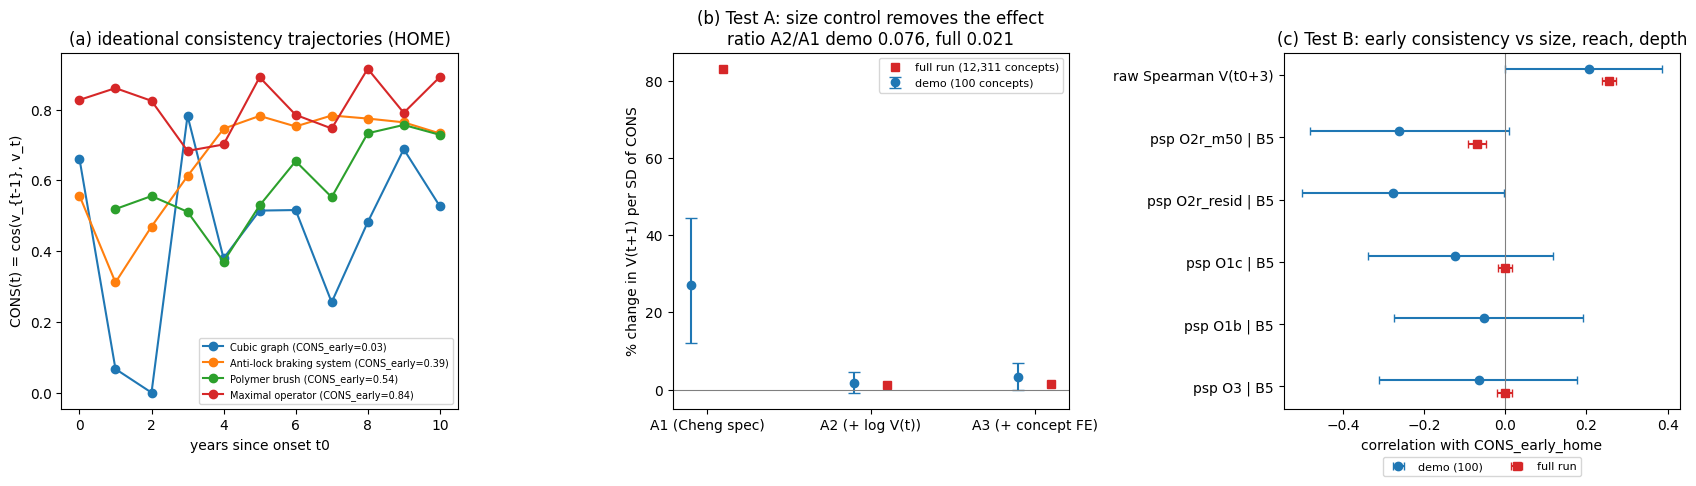

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# (a) CONS trajectories of a few concepts (most / least consistent early + two in between)
fhh = feat[(feat.build == "HOME")].merge(meta[["ci", "t0"]], on="ci")
fhh["age"] = fhh.year - fhh.t0
order = st.dropna(subset=["CONS_early_home"]).sort_values("CONS_early_home").ci.to_numpy()
show = [order[0], order[len(order) // 3], order[2 * len(order) // 3], order[-1]]
names = dict(zip(st_demo.ci, st_demo.name))
for c in show:
    g = fhh[fhh.ci == c]
    ax[0].plot(g.age, g.CONS, marker="o", label=f"{names[c][:28]} (CONS_early={st.set_index('ci').CONS_early_home[c]:.2f})")
ax[0].set_xlabel("years since onset t0")
ax[0].set_ylabel("CONS(t) = cos(v_{t-1}, v_t)")
ax[0].set_title("(a) ideational consistency trajectories (HOME)")
ax[0].legend(fontsize=7)

# (b) Test A ladder: demo vs full run
labs = ["A1 (Cheng spec)", "A2 (+ log V(t))", "A3 (+ concept FE)"]
dm = [HJ[m]["coef"]["zCONS"] for m in ["A1", "A2", "A3"]]
fr_ = [H[P + "A1.coef.zCONS.pct_per_sd"], H[P + "A2.coef.zCONS.pct_per_sd"], H[P + "A3.coef.zCONS.pct_per_sd"]]
xs = np.arange(3)
ax[1].errorbar(xs - 0.1, [100 * c["pct_per_sd"] for c in dm],
               yerr=[[100 * (c["pct_per_sd"] - c["pct_ci"][0]) for c in dm], [100 * (c["pct_ci"][1] - c["pct_per_sd"]) for c in dm]],
               fmt="o", capsize=4, label=f"demo ({N_CONCEPTS} concepts)")
ax[1].plot(xs + 0.1, [100 * v for v in fr_], "s", color="C3", label="full run (12,311 concepts)")
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_xticks(xs, labs)
ax[1].set_ylabel("% change in V(t+1) per SD of CONS")
ax[1].set_title(f"(b) Test A: size control removes the effect\nratio A2/A1 demo {HJ['ratio_boot']['ratio']:.3f}, full {H[P + 'ratio_boot.ratio']:.3f}")
ax[1].legend(fontsize=8)

# (c) Test B forest
items = [("raw Spearman V(t0+3)", vB["B_raw_spearman_V_t0p3"], f"volume.{PRIMARY}|volume.B_raw_spearman_V_t0p3")]
for y in ["O2r_m50", "O2r_resid", "O1c", "O1b", "O3"]:
    items.append((f"psp {y} | B5", pB["psp"][y], f"trait.{PRIMARY}|CONS_early_home.psp.{y}"))
for k, (lab, r, key) in enumerate(items):
    if r["rho"] is not None:
        ax[2].errorbar(r["rho"], k - 0.1, xerr=[[r["rho"] - r["ci"][0]], [r["ci"][1] - r["rho"]]], fmt="o", color="C0", capsize=3,
                       label=f"demo ({N_CONCEPTS})" if k == 0 else None)
    if S_ + key + ".rho" in H:
        fr_ci = H.get(S_ + key + ".ci")
        ax[2].errorbar(H[S_ + key + ".rho"], k + 0.1, xerr=None if fr_ci is None else [[H[S_ + key + ".rho"] - fr_ci[0]], [fr_ci[1] - H[S_ + key + ".rho"]]],
                       fmt="s", color="C3", capsize=3, label="full run" if k == 0 else None)
ax[2].axvline(0, color="grey", lw=0.8)
ax[2].set_yticks(range(len(items)), [i[0] for i in items])
ax[2].invert_yaxis()
ax[2].set_xlabel("correlation with CONS_early_home")
ax[2].set_title("(c) Test B: early consistency vs size, reach, depth")
ax[2].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()